In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/karan12singh123/dataset123/test/IM-0025_normal_-0001.jpeg
/kaggle/input/datasets/karan12singh123/dataset123/test/person629_bacteria_2506.jpeg
/kaggle/input/datasets/karan12singh123/dataset123/test/person630_bacteria_2515.jpeg
/kaggle/input/datasets/karan12singh123/dataset123/test/person629_bacteria_2509.jpeg
/kaggle/input/datasets/karan12singh123/dataset123/test/IM-0021_normal_-0001.jpeg
/kaggle/input/datasets/karan12singh123/dataset123/test/IM-0017_normal_-0001.jpeg
/kaggle/input/datasets/karan12singh123/dataset123/test/person637_bacteria_2529.jpeg
/kaggle/input/datasets/karan12singh123/dataset123/test/person637_bacteria_2528.jpeg
/kaggle/input/datasets/karan12singh123/dataset123/test/person630_bacteria_2514.jpeg
/kaggle/input/datasets/karan12singh123/dataset123/test/person629_bacteria_2507.jpeg
/kaggle/input/datasets/karan12singh123/dataset123/test/person632_bacteria_2521.jpeg
/kaggle/input/datasets/karan12singh123/dataset123/test/person636_virus_1217.jpeg
/kag

In [3]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout,BatchNormalization
from tensorflow.keras.layers import RandomRotation,RandomFlip,RandomTranslation,RandomZoom,Input
from tensorflow.keras.models import Sequential ,Model

2026-06-20 13:35:56.243461: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781962556.438107      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781962556.491762      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781962556.954570      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781962556.954615      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781962556.954618      58 computation_placer.cc:177] computation placer alr

In [4]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/working/train_binary',
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(224,224),
    batch_size=32
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/working/train_binary',
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(224,224),
    batch_size=32
)

print(train_ds.class_names)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.


I0000 00:00:1781962570.783879      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
['NORMAL', 'PNEUMONIA']


In [5]:
from tensorflow.keras.callbacks import EarlyStopping
callback=EarlyStopping(patience=3,
                      min_delta=.00001,
                      monitor='val_accuracy',
                      restore_best_weights=True,
                       verbose=1
                      )

In [6]:
img_gen=Sequential()
img_gen.add(RandomRotation(.2))
img_gen.add(RandomZoom(.2))
img_gen.add(RandomFlip('horizontal_and_vertical'))
img_gen.add(RandomTranslation(.2,.2))

In [7]:
import kerastuner as kt

/tmp/ipykernel_58/1654478174.py:1: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  import kerastuner as kt


In [8]:
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import DenseNet121
def build_model(hp):
    
    base_model=DenseNet121(weights='imagenet',
                       include_top=False,
                          input_shape=(224,224,3))
    
    model=Sequential()
    
    optimizer=hp.Choice('optimizer',values=['adam','rmsprop'])
    layers=hp.Int('layers',1,5)
    dropout_rate = hp.Float(
    'dropout_rate',
    min_value=0.1,
    max_value=0.5,
    step=0.1
)
    model.add(Input(shape=(224,224,3)))
    model.add(img_gen)
    
    model.add(base_model)
    
    base_model.trainable = True

    for layer in base_model.layers[:-50]:
        layer.trainable = False
    model.add(GlobalAveragePooling2D())
    
    for i in range(layers):
        units = hp.Int(f'units_{i}',min_value=32,max_value=256,step=32)
        activation = hp.Choice(f'activation_{i}',values=['relu','tanh'])
        model.add(Dense(units=units,activation=activation))
        model.add(Dropout(dropout_rate))
        
    model.add(Dense(1,activation='sigmoid'))
    
    model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy'])
    
    return model

In [9]:
tuner=kt.RandomSearch(build_model,objective='val_accuracy',max_trials=5)
tuner.search(train_ds,epochs=5,validation_data=valid_ds,callbacks=[callback])


Trial 5 Complete [00h 01m 55s]
val_accuracy: 0.9213806390762329

Best val_accuracy So Far: 0.9367210268974304
Total elapsed time: 00h 09m 44s


In [10]:
from tensorflow.keras.optimizers import Adam

model = tuner.get_best_models(num_models=1)[0]

model.compile(
    optimizer=Adam(learning_rate=1e-6),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print(tuner.get_best_hyperparameters(num_trials=1)[0].values)

model.summary()

{'optimizer': 'rmsprop', 'layers': 3, 'dropout_rate': 0.1, 'units_0': 96, 'activation_0': 'relu', 'units_1': 32, 'activation_1': 'relu', 'units_2': 32, 'activation_2': 'relu'}


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 52 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 96)             │        98,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,140,097 (27.24 MB)

 Trainable params: 1,178,241 (4.49 MB)

 Non-trainable params: 5,961,856 (22.74 MB)

In [11]:
history=model.fit(train_ds,validation_data=valid_ds,epochs=50,initial_epoch=5,callbacks=callback)

Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 43s 174ms/step - accuracy: 0.9101 - loss: 0.2288 - val_accuracy: 0.9463 - val_loss: 0.1547
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 18s 139ms/step - accuracy: 0.9159 - loss: 0.2180 - val_accuracy: 0.9415 - val_loss: 0.1586
Epoch 8/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 19s 141ms/step - accuracy: 0.9094 - loss: 0.2256 - val_accuracy: 0.9406 - val_loss: 0.1613
Epoch 9/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 18s 140ms/step - accuracy: 0.9168 - loss: 0.2032 - val_accuracy: 0.9406 - val_loss: 0.1597
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 6.


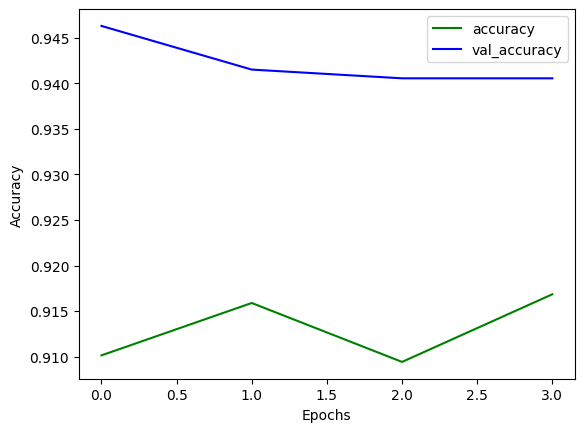

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],label='accuracy',color='green')
plt.plot(history.history['val_accuracy'],label='val_accuracy',color='blue')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

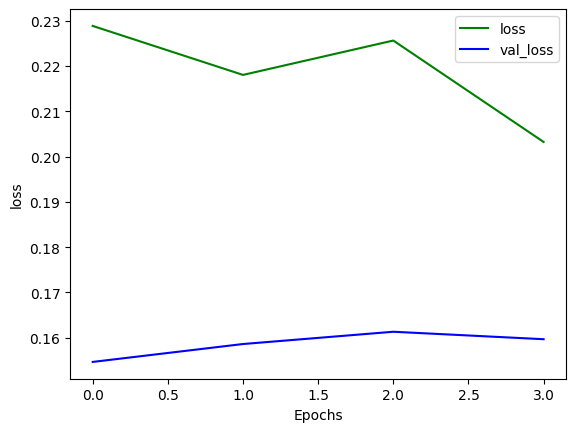

In [13]:

plt.plot(history.history['loss'],label='loss',color='green')
plt.plot(history.history['val_loss'],label='val_loss',color='blue')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [29]:
model.save('pneumonia_detector.keras')


In [24]:
from tensorflow.keras.models import load_model
import numpy as np
import tensorflow as tf
model = load_model('xray_model.keras')
img=tf.keras.utils.load_img('/kaggle/input/datasets/karan12singh123/dataset123/train/VIRAL/person1004_virus_1686.jpeg',
                           target_size=(224,224))
img_array=tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
prediction = model.predict(img_array)

print(prediction)

if prediction[0][0] > 0.5:

    print("PNEUMONIA")

else:

    print("NORMAL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
[[0.99325705]]
PNEUMONIA


In [26]:
import numpy as np

true = []
pred = []

for img, labels in valid_ds:

    preds = model.predict(img, verbose=0)

    pred_labels = (preds > 0.5).astype(int)

    true.extend(labels.numpy())
    pred.extend(pred_labels.flatten())

In [27]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true,
        pred,
        target_names=train_ds.class_names
    )
)

              precision    recall  f1-score   support

      NORMAL       0.91      0.86      0.88       249
   PNEUMONIA       0.96      0.97      0.96       794

    accuracy                           0.95      1043
   macro avg       0.93      0.92      0.92      1043
weighted avg       0.95      0.95      0.95      1043



[[215  34]
 [ 22 772]]


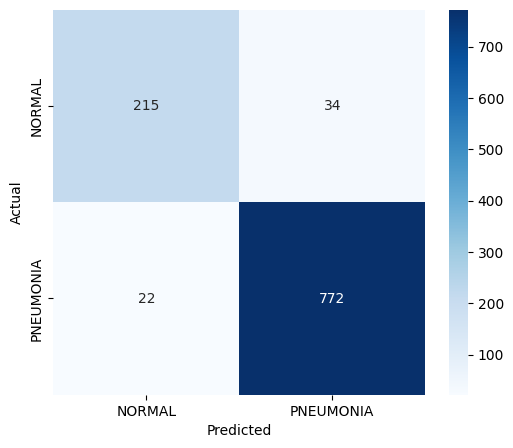

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true, pred)

print(cm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_ds.class_names,
    yticklabels=train_ds.class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
print(train_ds.class_names)

['NORMAL', 'PNEUMONIA']
